<a href="https://colab.research.google.com/github/hueglijoshua/CVI03.HS24-Computer-Vision/blob/main/04b_YOLO_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import os
import json
import shutil
import xml.etree.ElementTree as ET
import pandas as pd
import yaml
import numpy as np
from datetime import datetime
import shutil
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab.patches import cv2_imshow

# Segmentation using YOLO bounding boxes & masks - Part 2

In Part 1 we selected the best performing model, now we are going to test it on unseen test data.

## YOLO Processing Pipeline

1. **Image Preprocessing**  
   - **Resize**: By default, the input image is resized (and sometimes padded with gray bars) to match the model’s expected dimension (e.g., 640×640), preserving aspect ratio.  
   - **Normalization**: Pixel values are typically scaled to [0,1] (e.g., dividing by 255).  

2. **Model Forward Pass**  
   - The processed image is fed into the YOLO model (a convolutional neural network).  
   - The network outputs raw predictions of bounding boxes, masks, class scores, etc.

3. **Postprocessing**  
  - **Confidence Thresholding** (Same as Object Detection)
The model assigns a confidence score to each detected object.
Detections below a predefined confidence threshold (e.g., 0.25) are discarded.
  - **Non-Maximum Suppression (NMS)** (Same as Object Detection)
NMS is applied to bounding boxes to eliminate redundant or overlapping detections.
The IoU threshold (default ~0.45) determines when to suppress overlapping detections.
  - **Mask Extraction** (Segmentation-Specific Step)
Each detected object has an associated segmentation mask.
YOLO outputs a compressed representation of the masks, typically using a low-dimensional embedding.
These masks need to be upsampled (rescaled) to the original image resolution.
Interpolation techniques (e.g., bilinear or nearest-neighbor) are used to restore mask resolution.
  - **Thresholding the Masks**
The mask is typically sigmoid-activated, giving values between 0 and 1.
A binary threshold (e.g., 0.5) is applied to convert soft masks into binary masks (foreground = 1, background = 0).
This step ensures that each pixel is either assigned to the object or ignored.
  - **Applying the Masks to the Image**
The binary mask is multiplied by the detected bounding box region.
This removes any false positive pixels outside the detected object.


In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.2/922.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from google.colab import drive, files

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Set dataset path
dataset_path = "/content/drive/MyDrive/data_segmentation_yolo"

drive_model_dir = "/content/drive/MyDrive/yolo_seg-model_comparison"


## Load the model

The best performing model was the YOLO 11 medium size, which we are now going to load for further evaluation.

In [6]:
best_model = "yolo_11m-seg.pt"
model_path = os.path.join(drive_model_dir, best_model)
# Load the trained model
model = YOLO(model_path)

We can use the following code to evaluate the model on the test results. While these results may slightly deviate from our own calculations, they provide a useful sanity check. For example, if our calculations yield an mAP50 of 0.9, but the values from Ultraytics are significantly lower, it suggests there may be an error somewhere. Despite relying on the provided results, we will still calculate some metrics ourselves to gain deeper insights.

In [7]:
test_results = model.val(imgsz=640, split='test',conf=0.25)

Ultralytics 8.3.85 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m-seg summary (fused): 138 layers, 22,336,083 parameters, 0 gradients, 123.0 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 101MB/s]
val: Scanning /content/drive/MyDrive/data_segmentation_yolo/test/labels... 61 images, 0 backgrounds, 0 corrupt: 100%|██████████| 61/61 [01:42<00:00,  1.69s/it]

val: New cache created: /content/drive/MyDrive/data_segmentation_yolo/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:05<00:00,  1.34s/it]


                   all         61         67      0.666      0.417      0.506      0.233      0.632      0.384      0.477       0.17
Speed: 7.1ms preprocess, 30.1ms inference, 0.0ms loss, 7.2ms postprocess per image
Results saved to runs/segment/val


We create several different functions to allow for detailed analysis. First, we calculate the intersection over union (IoU) and match boxes based on the IoU. These functin will also be used when visualizing selected x-ray images with pedicted and ground truth boxes.

In [118]:
def intersection_over_union(boxA, boxB):
    """
    Computes IoU between two boxes: [xmin, ymin, xmax, ymax].
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = boxAArea + boxBArea - interArea + 1e-6

    return interArea / union

def match_boxes_iou(pred_boxes, gt_boxes, iou_thresh):
    """
    Matches predicted boxes with ground truth based on IoU threshold.
    Returns:
      - is_tp: List of booleans indicating if a predicted box is a true positive.
      - is_fp: List of booleans indicating if a predicted box is a false positive.
      - unmatched_gt: Count of unmatched ground truth boxes (False Negatives).
    """
    used = np.zeros(len(gt_boxes), dtype=bool)  # Tracks matched GT boxes
    is_tp = []
    is_fp = []

    for pb in pred_boxes:
        best_iou = 0.0
        best_idx = -1
        for i, gb in enumerate(gt_boxes):
            if used[i]:
                continue  # Skip already matched GT boxes
            iou = intersection_over_union(pb, gb)

            if iou > best_iou:
                best_iou = iou
                best_idx = i

        if best_iou >= iou_thresh and best_idx >= 0:
            is_tp.append(True)
            is_fp.append(False)
            used[best_idx] = True  # Mark this GT as matched
        else:
            is_tp.append(False)
            is_fp.append(True)  # Count this as a false positive

    unmatched_gt = np.sum(~used)  # False Negatives = Unmatched GT boxes
    return np.array(is_tp), np.array(is_fp), unmatched_gt



In [124]:
def visualize_detections(dataset_path, folder, image_name,
                         model_path,
                         pred_boxes=None):
    """
    Visualizes ground truth vs. predicted bounding boxes and segmentation masks for a given image.

    Parameters:
    - dataset_path (str): Path to the dataset directory.
    - folder (str): The dataset split to use ("train", "val", or "test").
    - image_name (str): The filename of the image (e.g., "IMG0003733.jpg").
    - model_path (str): Path to the trained YOLO model.
    """
    # Define paths for images and labels
    image_path = os.path.join(dataset_path, folder, "images", image_name)
    annotation_path = os.path.join(dataset_path, folder, "labels", os.path.splitext(image_name)[0] + ".txt")

    # Verify the image exists
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return

    print(f"Selected Image: {image_path}")
    print(f"Annotation File: {annotation_path if os.path.exists(annotation_path) else 'No annotation found'}")

    # Load the image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for matplotlib

    # Get image dimensions
    height, width, _ = image.shape

    # Load ground truth bounding boxes
    ground_truth_boxes = load_ground_truth(image_name, width, height)

    if pred_boxes is None:
        # Load trained YOLO model
        model = YOLO(model_path)

        # Run inference on the selected image
        results = model(image_path)

        # Extract predicted bounding boxes and masks
        pred_boxes = []
        all_masks = []  # To store masks

        for result in results:
            for box, mask in zip(result.boxes, result.masks.data):
                x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get bounding box
                conf = box.conf[0].item()  # Confidence score
                mask = mask.cpu().numpy()  # Convert mask to numpy array
                pred_boxes.append((x1, y1, x2, y2, conf))
                all_masks.append(mask)

    # Plot Ground Truth (Green) vs. Predictions (Red) and Masks (Blue)
    plt.figure(figsize=(8, 8))
    plt.imshow(image)

    # Plot ground truth bounding boxes (Green)
    for (x1, y1, x2, y2) in ground_truth_boxes:
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='green', linewidth=2))
        plt.text(x1, y1 - 5, f"GT: fractured", color="green", fontsize=10,
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    # Plot predicted bounding boxes (Red) and Masks (Blue)
    for (x1, y1, x2, y2, conf), mask in zip(pred_boxes, all_masks):

        # Plot bounding box (Red)
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2))
        plt.text(x1, y2 + 15, f"Pred: {conf:.2f}", color="red", fontsize=10,
                verticalalignment='bottom',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

        # Plot the mask (Blue)
        mask_resized = cv2.resize(mask, (width, height), interpolation=cv2.INTER_LINEAR)
        mask_resized = np.expand_dims(mask_resized, axis=-1)  # Add an extra dimension for RGB
        mask_rgb = np.repeat(mask_resized, 3, axis=-1)  # Convert to 3-channel mask (RGB)
        mask_rgb = mask_rgb * np.array([0, 0, 255])  # Blue color for mask
        plt.imshow(mask_rgb, alpha=0.2)  # Show mask with some transparency

    plt.axis("off")
    plt.title("Ground Truth (Green) vs. Predicted (Red) and Masks (Blue)")
    plt.show()

    print(f"Number of Ground Truth Boxes: {len(ground_truth_boxes)}")
    print(f"Number of Predicted Boxes: {len(pred_boxes)}")
    gt_np = np.array([box[:4] for box in ground_truth_boxes])
    pred_np = np.array([box[:4] for box in pred_boxes])

    for i, pbox in enumerate(pred_np):
        best_iou = 0.0
        for gbox in gt_np:
            iou_val = intersection_over_union(pbox, gbox)
            if iou_val > best_iou:
                best_iou = iou_val
        print(f"Predicted box {i} best IoU: {best_iou:.3f}")

## Visualize predicted and ground truth boxes

Selected Image: /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003399.jpg
Annotation File: /content/drive/MyDrive/data_segmentation_yolo/test/labels/IMG0003399.txt
Annotation Parts: ['0', '0.343164', '0.572687', '0.369973', '0.568282', '0.372654', '0.535242', '0.340483', '0.533040', '0.332440', '0.550661']

image 1/1 /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003399.jpg: 640x544 1 fractured, 51.6ms
Speed: 3.7ms preprocess, 51.6ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 544)


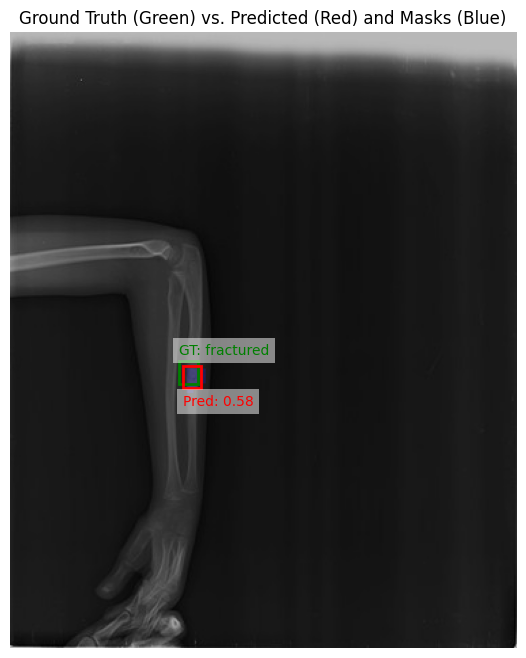

Number of Ground Truth Boxes: 1
Number of Predicted Boxes: 1
Predicted box 0 best IoU: 0.472


In [126]:
import random
folder = 'test'
image_dir = f"{dataset_path}/{folder}/images/"
# List all images in the validation folder
image_files = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

random_image = random.choice(image_files)
visualize_detections(dataset_path,folder, random_image, model_path)

Selected Image: /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003383.jpg
Annotation File: /content/drive/MyDrive/data_segmentation_yolo/test/labels/IMG0003383.txt
Annotation Parts: ['0', '0.340483', '0.433921', '0.410188', '0.429515', '0.404826', '0.396476', '0.378016', '0.381057', '0.345845', '0.383260', '0.332440', '0.409692']

image 1/1 /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003383.jpg: 640x544 2 fractureds, 48.1ms
Speed: 2.3ms preprocess, 48.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 544)


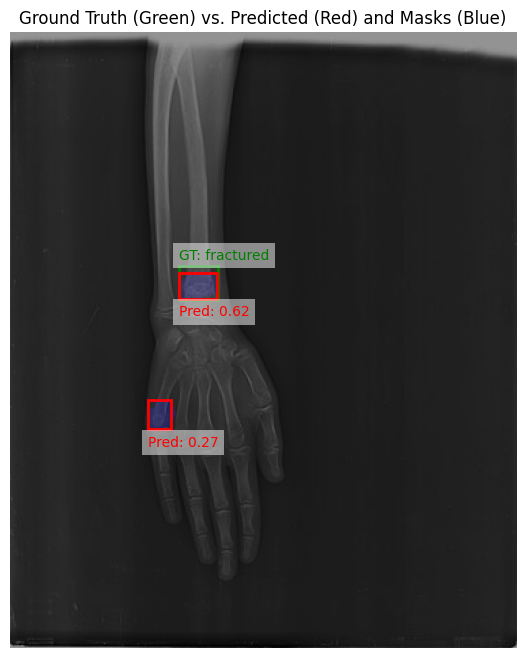

Number of Ground Truth Boxes: 1
Number of Predicted Boxes: 2
Predicted box 0 best IoU: 0.734
Predicted box 1 best IoU: 0.000


In [127]:
visualize_detections(dataset_path, folder, "IMG0003383.jpg", model_path)

## Evaluate results

In [42]:
test_images_dir = f"{dataset_path}/test/images"
test_labels_dir = f"{dataset_path}/test/labels"

model = YOLO(model_path)

test_images = [f for f in os.listdir(test_images_dir)
               if f.lower().endswith((".jpg", ".png", ".jpeg"))]

# We want the class ID for "fractured"
fractured_id = None
for idx, name in model.names.items():
    if name == "fractured":
        fractured_id = idx
        break

if fractured_id is None:
    raise ValueError("No class named 'fractured' in model.names!")

print(f"Class ID for 'fractured': {fractured_id}")

Class ID for 'fractured': 0


In [43]:
def compute_precision_recall_curve(pred_scores, is_tp, is_fp, total_gt_boxes):
    """
    Compute precision-recall values at different confidence thresholds.
    """
    # Sort predictions by confidence score (high to low)
    sorted_indices = np.argsort(-np.array(pred_scores))
    is_tp_sorted = np.array(is_tp)[sorted_indices]
    is_fp_sorted = np.array(is_fp)[sorted_indices]

    # Cumulative sum to compute precision & recall step-by-step
    cum_tp = np.cumsum(is_tp_sorted)
    cum_fp = np.cumsum(is_fp_sorted)

    precision_curve = cum_tp / (cum_tp + cum_fp)  # Precision at each threshold
    recall_curve = cum_tp / total_gt_boxes  # Recall at each threshold

    return precision_curve, recall_curve

def calculate_average_precision(precision: np.array, recall: np.array):
    """
    Calculate the average precision for a given precision-recall curve.
    """
    steps = recall[1:] - recall[:-1]
    average_precision = (steps * precision[:-1]).sum()
    return average_precision

In [44]:
def compute_ap_per_iou(all_gt, all_pred, all_scores, iou_thresholds, model_name, plot = False):
    """Computes AP for different IoU thresholds and plots PR curves."""
    ap_per_iou = {}
    if plot:
        plt.figure(figsize=(8, 6))

    for iou_thresh in iou_thresholds:
        matched_predictions = []
        total_false_negatives = 0

        for gt_boxes, pred_boxes, pred_scores in zip(all_gt, all_pred, all_scores):
            gt_boxes = np.array(gt_boxes)
            pred_boxes = np.array(pred_boxes)
            pred_scores = np.array(pred_scores)

            if len(pred_boxes) == 0:
                total_false_negatives += len(gt_boxes)
                continue

            is_tp, is_fp, fn = match_boxes_iou(pred_boxes, gt_boxes, iou_thresh)
            total_false_negatives += fn

            for tp, fp, s in zip(is_tp, is_fp, pred_scores):
                matched_predictions.append({"score": s, "is_tp": tp, "is_fp": fp})

        if len(matched_predictions) == 0:
            continue

        scores_array = np.array([p["score"] for p in matched_predictions])
        labels_array = np.array([1 if p["is_tp"] else 0 for p in matched_predictions])
        false_positives_array = np.array([1 if p["is_fp"] else 0 for p in matched_predictions])

        precision_curve, recall_curve = compute_precision_recall_curve(
            scores_array, labels_array, false_positives_array, 67
        )

        precision_recall = np.column_stack((precision_curve, recall_curve))
        precision_recall_interpolated = np.array(
            [
                (precision_recall[i:, 0].max(), precision_recall[i, 1])
                for i in range(precision_recall.shape[0] - 1)
            ]
        )

        ap = calculate_average_precision(
            precision_recall_interpolated[:, 0], precision_recall_interpolated[:, 1]
        )
        ap_per_iou[iou_thresh] = ap
        if plot:
            plt.plot(
                precision_recall_interpolated[:, 1],
                precision_recall_interpolated[:, 0],
                label=f"IoU={iou_thresh:.2f}",
            )

    if plot:
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curves ({model_name})")
        plt.grid(True)
        plt.legend()
        plt.show()

    return ap_per_iou

In [45]:
def compute_confusion_matrix(all_gt, all_pred, model_name, axes):
    """
    Computes and displays a 2x2 confusion matrix (TP, FP, FN, TN) for a specific model.
    This version includes no-fracture images as true negatives and counts
    each predicted box on a no-fracture image as a false positive.
    """

    y_true = []
    y_pred = []

    # Loop through each image
    for gt_boxes, pred_boxes in zip(all_gt, all_pred):
        # CASE 1: No GT boxes
        if len(gt_boxes) == 0:
            # If the model also predicts no boxes => Single True Negative
            if len(pred_boxes) == 0:
                y_true.append(0)  # Actual: no fracture
                y_pred.append(0)  # Predicted: no fracture
            else:
                # If the model predicts >=1 box => each one is a False Positive
                for _ in pred_boxes:
                    y_true.append(0)  # Actual: no fracture
                    y_pred.append(1)  # Predicted: fracture
        else:
            # CASE 2: One or more GT boxes (standard matching)
            # Track which GT boxes have been matched
            gt_used = [False] * len(gt_boxes)

            # For each predicted box, find the best GT match (if any)
            for pbox in pred_boxes:
                best_iou = 0.0
                best_idx = -1
                for i, gt_box in enumerate(gt_boxes):
                    if not gt_used[i]:
                        iou_val = intersection_over_union(pbox, gt_box)
                        if iou_val > best_iou:
                            best_iou = iou_val
                            best_idx = i

                if best_iou >= 0.5 and best_idx >= 0:
                    # True Positive
                    gt_used[best_idx] = True
                    y_true.append(1)  # Actual: fracture
                    y_pred.append(1)  # Predicted: fracture
                else:
                    # No match => False Positive
                    y_true.append(0)  # Actual: no fracture (for this "box" perspective)
                    y_pred.append(1)  # Predicted: fracture

            # Any ground-truth box left unmatched => False Negative
            for i, used in enumerate(gt_used):
                if not used:
                    y_true.append(1)  # Actual: fracture
                    y_pred.append(0)  # Predicted: no fracture

    # Build confusion matrix:
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

    # Extract values
    TP, FN = cm[0, 0], cm[0, 1]
    FP, TN = cm[1, 0], cm[1, 1]

    # Calculate metrics
    precision = TP / (TP + FP + 1e-6) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN + 1e-6) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP + 1e-6) if (TN + FP) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6) if (precision + recall) > 0 else 0.0

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Fracture Found", "No Fracture Found"])

    # Plot on either a given Axes or a new figure
    if axes is not None:
        disp.plot(cmap=plt.cm.Blues, ax=axes, colorbar=False)
        axes.set_title(f"{model_name.strip('.pt')}, IoU>=0.5")
        axes.set_yticklabels(["Fracture Found", "No Fracture Found"], rotation=90, va='center')

        # Add metrics as text below the confusion matrix
        metrics_text = f"Precision: {precision:.2f}\nRecall: {recall:.2f}\nSpecificity: {specificity:.2f}\nF1-score: {f1_score:.2f}"
        axes.text(0.5, -0.4, metrics_text, fontsize=12, ha='center', va='center', transform=axes.transAxes)
    else:
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"{model_name.strip('.pt')}, IoU>=0.5")
        plt.gca().set_yticklabels(["Fracture Found", "No Fracture Found"], rotation=90, va='center')

        # Add metrics as text below the confusion matrix
        plt.figtext(0.5, -0.1, f"Precision: {precision:.2f} | Recall: {recall:.2f} | Specificity: {specificity:.2f} | F1-score: {f1_score:.2f}",
                    ha="center", fontsize=12)
        plt.show()

In [46]:
def run_model(model, image_path):
    """Runs a YOLO model on the given image and returns predicted boxes and scores."""
    results = model(image_path, imgsz=640, conf=0.25)

    pred_boxes = []
    scores = []
    for r in results:
        for box in r.boxes:
            cls_pred = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            if cls_pred == fractured_id:
                pred_boxes.append([x1, y1, x2, y2])
                scores.append(conf)

    return pred_boxes, scores

In the next step, we loop through all our test images and saved ground truth boxes, predicted boxes and scores in dedicated lists.

In [47]:
all_gt = []
all_pred = []
all_scores = []

for image_name in tqdm(test_images):
    image_path = os.path.join(test_images_dir, image_name)
    image = cv2.imread(image_path)
    if image is None:
        continue  # Skip broken image
    img_h, img_w = image.shape[:2]

    gt_boxes = load_ground_truth(image_name, img_w, img_h)
    pred_boxes, scores = run_model(model, image_path)

    all_gt.append(gt_boxes)
    all_pred.append(pred_boxes)
    all_scores.append(scores)

  0%|          | 0/61 [00:00<?, ?it/s]

Annotation Parts: ['0', '0.538874', '0.475771', '0.568365', '0.504405', '0.581769', '0.497797', '0.565684', '0.466960', '0.544236', '0.447137', '0.530831', '0.455947']

image 1/1 /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003311.jpg: 640x544 (no detections), 48.1ms
Speed: 3.2ms preprocess, 48.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 544)


  2%|▏         | 1/61 [00:00<00:26,  2.26it/s]

Annotation Parts: ['0', '0.560322', '0.513216', '0.560322', '0.535242', '0.573727', '0.544053', '0.600536', '0.537445', '0.587131', '0.506608']
Annotation Parts: ['0', '0.557641', '0.337004', '0.533512', '0.365639', '0.552279', '0.383260', '0.571046', '0.356828']

image 1/1 /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003373.jpg: 640x544 1 fractured, 47.3ms
Speed: 3.5ms preprocess, 47.3ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 544)
Annotation Parts: ['0', '0.487936', '0.491189', '0.563003', '0.502203', '0.579088', '0.484581', '0.576408', '0.451542', '0.525469', '0.440529', '0.482574', '0.449339']

image 1/1 /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003686.jpg: 640x544 1 fractured, 47.2ms
Speed: 2.2ms preprocess, 47.2ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 544)


  5%|▍         | 3/61 [00:00<00:09,  6.05it/s]

...

 95%|█████████▌| 58/61 [00:03<00:00, 20.04it/s]

Annotation Parts: ['0', '0.453083', '0.548458', '0.439678', '0.563877', '0.455764', '0.579295', '0.501340', '0.563877', '0.495979', '0.544053']

image 1/1 /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003332.jpg: 640x544 (no detections), 24.2ms
Speed: 3.4ms preprocess, 24.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 544)
Annotation Parts: ['0', '0.455764', '0.365639', '0.469169', '0.405286', '0.517426', '0.431718', '0.512064', '0.392070', '0.474531', '0.334802', '0.461126', '0.334802']

image 1/1 /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003520.jpg: 640x544 (no detections), 23.4ms
Speed: 3.5ms preprocess, 23.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 544)


 98%|█████████▊| 60/61 [00:03<00:00, 19.60it/s]

Annotation Parts: ['0', '0.490617', '0.343612', '0.530831', '0.365639', '0.576408', '0.356828', '0.579088', '0.339207', '0.568365', '0.332599', '0.538874', '0.339207', '0.514745', '0.321586', '0.490617', '0.323789']

image 1/1 /content/drive/MyDrive/data_segmentation_yolo/test/images/IMG0003397.jpg: 640x544 1 fractured, 24.9ms
Speed: 3.3ms preprocess, 24.9ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 544)


100%|██████████| 61/61 [00:03<00:00, 17.31it/s]


We know that we have 61 test images, so let's check if our 3 lists vontain 61 elements:

In [48]:
print(len(all_gt), len(all_pred), len(all_scores))

61 61 61


We compute the Average Precision (AP) across IoU thresholds ranging from 0.5 to 1.0 and visualize the results using a Precision-Recall curve.

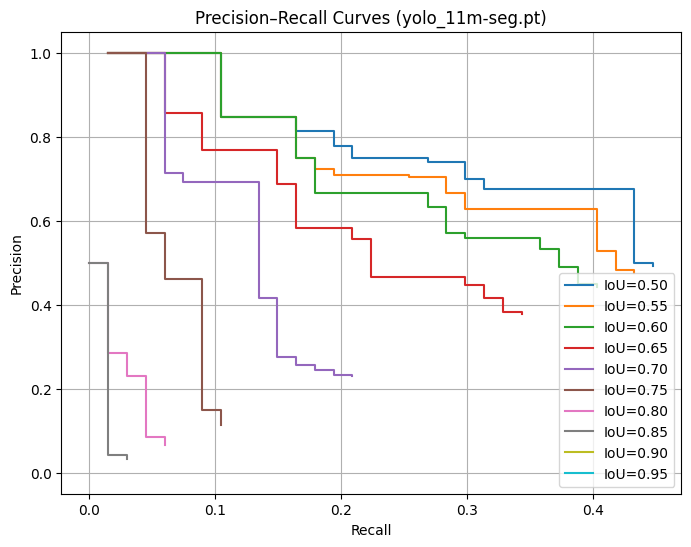

In [49]:
# Compute metrics
iou_thresholds = np.arange(0.5, 1.0, 0.05)
ap_per_iou = compute_ap_per_iou(
    all_gt, all_pred, all_scores, iou_thresholds, best_model, plot = True
)

In [50]:
for iou, ap in ap_per_iou.items():
    print(f"IoU {iou:.2f}: AP = {ap:.3f}")

mean_ap = np.mean(list(ap_per_iou.values()))
print(f"Mean Average Precision (mAP50-95): {mean_ap:.3f}")

IoU 0.50: AP = 0.341
IoU 0.55: AP = 0.316
IoU 0.60: AP = 0.284
IoU 0.65: AP = 0.214
IoU 0.70: AP = 0.118
IoU 0.75: AP = 0.054
IoU 0.80: AP = 0.016
IoU 0.85: AP = 0.008
IoU 0.90: AP = 0.000
IoU 0.95: AP = 0.000
Mean Average Precision (mAP50-95): 0.135


For the unseen test data the model has a mean Average Precision (mAP50-95) of 0.135 and the average precision at an IoU>0.5 is 0.341. These values are smaller compared to the validation data.

## Confusion matrix

We create a confusion matrix based on whether the model detected a box with IoU>=0.5 to that of the ground truth.

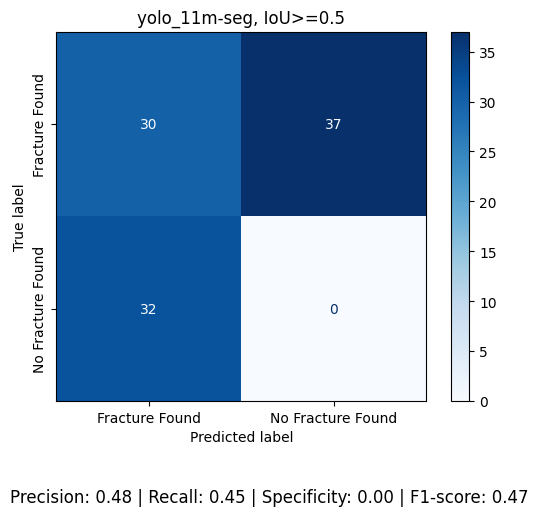

In [51]:
compute_confusion_matrix(
    all_gt, all_pred, best_model, axes = None
)

**Fractures in the Dataset**
- **True Positives (TP) = 30**: These are correctly detected fractures. The model predicted a fracture where an actual fracture exists.  
- **False Negatives (FN) = 37**: These are missed fractures. The model failed to detect these actual fractures, which would be an issue in medical applications.

**No Fractures in the Dataset**
- **False Positives (FP) = 32**: These are incorrect detections. The model predicted a fracture when there was none.  
- **True Negatives (TN) = 0**: Since the dataset does not contain any images without fractures, the model was never tested on truly negative cases.

**Performance Metrics**
- Precision: When the model predicts a fracture, it is correct 48% of the time.
- Recall (Sensitivity): The model correctly identifies 45% of actual fractures.
- Specificity: Since there are no images without fractures in the dataset, true negatives cannot be calculated. This means we cannot measure the model’s ability to correctly classify "no fracture" images.
- F1 Score: balance between Precision and Recall - 47%

The results are not very convincing.